# 1. Загрузка данных

In [ ]:
import pandas as pd

# Загрузка файла 'heart.csv' с Google Диска
# Убедитесь, что файл 'heart.csv' находится в корне вашей папки 'Мой диск' на Google Диске
df = pd.read_csv('/content/drive/MyDrive/heart.csv')

# Отображение первых 5 строк DataFrame для проверки данных
display(df.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# 2. Разделение данных на обучающую и тестовую выборки

In [ ]:
from sklearn.model_selection import train_test_split

# Определение признаков (X) и целевой переменной (y)
# 'target' - это целевая переменная в текущем DataFrame, остальные - признаки
X = df.drop('target', axis=1)
y = df['target']

# Разделение данных на обучающую и тестовую выборки
# test_size=0.2 означает, что 20% данных будут использованы для тестирования
# random_state=42 обеспечивает воспроизводимость результатов
# stratify=y гарантирует, что доли классов в y будут одинаковы в обучающей и тестовой выборках
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки (признаки): {X_train.shape}")
print(f"Размер тестовой выборки (признаки): {X_test.shape}")
print(f"Размер обучающей выборки (целевая переменная): {y_train.shape}")
print(f"Размер тестовой выборки (целевая переменная): {y_test.shape}")

Размер обучающей выборки (признаки): (242, 13)
Размер тестовой выборки (признаки): (61, 13)
Размер обучающей выборки (целевая переменная): (242,)
Размер тестовой выборки (целевая переменная): (61,)


### Разделение данных на обучающую и тестовую выборки

Разделение данных на обучающую (training) и тестовую (testing) выборки является фундаментальным шагом в машинном обучении и необходимо по нескольким причинам:

1.  **Оценка обобщающей способности модели**: Основная цель машинного обучения — создать модель, которая хорошо работает на *новых, ранее невиданных данных*, а не только на тех, на которых она обучалась. Если мы обучаем модель на всех доступных данных, а затем тестируем ее на тех же данных, мы получим завышенную оценку производительности. Модель может просто «запомнить» обучающие данные (что называется *переобучением*), но плохо справляться с реальными новыми случаями.

2.  **Предотвращение переобучения (Overfitting)**: Переобучение происходит, когда модель слишком хорошо подстраивается под обучающие данные, захватывая шум и случайные вариации, которые не являются частью истинной закономерности. Такая модель будет иметь высокую точность на обучающей выборке, но низкую на тестовой. Разделение данных позволяет выявить переобучение, так как производительность модели на тестовой выборке будет значительно хуже, чем на обучающей.

3.  **Независимая оценка**: Тестовая выборка действует как независимый набор данных, имитирующий «реальный мир». Модель никогда не видит эти данные во время обучения, поэтому ее производительность на тестовой выборке является честной и объективной оценкой того, как она будет работать в реальных условиях.

# 3. Обучение модели

In [ ]:
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

print("Обучение и оценка моделей:")

Обучение и оценка моделей:


## 3.1. Наивный байесовский классификатор

In [ ]:
# Инициализация модели Наивного Байеса
nb_model = GaussianNB()

# Обучение модели
nb_model.fit(X_train, y_train)

# Предсказания на тестовой выборке
y_pred_nb = nb_model.predict(X_test)

# Оценка точности модели
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Точность Наивного Байеса: {accuracy_nb:.4f}")

Точность Наивного Байеса: 0.8197


### Наивный байесовский классификатор (Naive Bayes Classifier)

**Что это?**
Наивный байесовский классификатор — это семейство простых вероятностных классификаторов, основанных на применении теоремы Байеса с «наивным» предположением о сильной независимости признаков. Это означает, что он предполагает, что наличие одного признака в классе не зависит от наличия любого другого признака.

**Как работает (очень упрощенно)?**
Он вычисляет вероятность того, что данный набор признаков принадлежит определенному классу, используя теорему Байеса. «Наивность» заключается в том, что он рассматривает каждый признак как независимый от других, что редко бывает в реальном мире, но на практике это часто работает удивительно хорошо.

**Зачем нужен?**
*   **Скорость**: Очень быстр в обучении и предсказании, так как требует только одного прохода по данным для вычисления вероятностей.
*   **Эффективность**: Хорошо работает на больших наборах данных.
*   **Простота**: Легко интерпретировать.
*   **Хорош для текста**: Часто используется в задачах классификации текста (например, спам-фильтры) и медицинских диагнозах, где признаки могут быть условно независимыми.

## 3.2. Логистическая регрессия

In [ ]:
# Инициализация модели Логистической регрессии
# Увеличение max_iter для обеспечения сходимости
# Solver 'liblinear' хорошо подходит для небольших наборов данных и бинарной классификации
log_reg_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

# Обучение модели
log_reg_model.fit(X_train, y_train)

# Предсказания на тестовой выборке
y_pred_lr = log_reg_model.predict(X_test)

# Оценка точности модели
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Точность Логистической регрессии: {accuracy_lr:.4f}")

Точность Логистической регрессии: 0.8033


### Логистическая регрессия (Logistic Regression)

**Что это?**
Несмотря на слово «регрессия» в названии, логистическая регрессия — это алгоритм **классификации**, а не регрессии. Она используется для предсказания вероятности того, что объект принадлежит к определенному классу (например, болен/здоров, да/нет).

**Как работает?**
Логистическая регрессия использует логистическую (сигмоидную) функцию, чтобы «сжать» выходные значения линейной комбинации признаков в диапазон от 0 до 1, который можно интерпретировать как вероятность. Если вероятность превышает некоторый порог (например, 0.5), объект относится к одному классу, в противном случае — к другому.

**Зачем нужна?**
*   **Интерпретируемость**: Результаты легко интерпретировать; коэффициенты модели показывают, как каждый признак влияет на вероятность принадлежности к классу.
*   **Эффективность**: Хорошо работает с линейно разделимыми данными.
*   **Простота**: Относительно проста в реализации и быстра в обучении.
*   **Базовая модель**: Часто используется как отправная точка (baseline) для сравнения с более сложными моделями.

## 3.3. K-ближайших соседей (KNN) - Подбор оптимального K

In [ ]:
k_values = range(1, 31) # Пробуем K от 1 до 30
accuracies = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    y_pred_knn = knn_model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_knn))

# Находим K с наилучшей точностью
best_k = k_values[np.argmax(accuracies)]
best_accuracy_knn = np.max(accuracies)

print(f"Лучшее значение K для KNN: {best_k}")
print(f"Точность KNN с лучшим K ({best_k}): {best_accuracy_knn:.4f}")

# Обучим и оценим финальную модель KNN с найденным лучшим K
final_knn_model = KNeighborsClassifier(n_neighbors=best_k)
final_knn_model.fit(X_train, y_train)
y_pred_final_knn = final_knn_model.predict(X_test)
accuracy_final_knn = accuracy_score(y_test, y_pred_final_knn)

# Это должно быть то же самое, что и best_accuracy_knn, но это подтверждает финальную модель
print(f"Финальная точность KNN модели с K={best_k}: {accuracy_final_knn:.4f}")

Лучшее значение K для KNN: 16
Точность KNN с лучшим K (16): 0.6721
Финальная точность KNN модели с K=16: 0.6721


### K-ближайших соседей (K-Nearest Neighbors, KNN)

**Что это?**
KNN — это непараметрический алгоритм классификации, который работает на основе принципа «близости» объектов. То есть, объект классифицируется в соответствии с большинством голосов его k ближайших соседей.

**Как работает?**
Когда требуется классифицировать новый объект:
1.  Алгоритм находит `k` объектов в обучающей выборке, которые наиболее похожи на новый объект (обычно используя метрику расстояния, такую как Евклидово расстояние).
2.  Затем он присваивает новому объекту тот класс, который является наиболее распространенным среди этих `k` ближайших соседей.

**Зачем нужен?**
*   **Простота**: Легко понять и реализовать.
*   **Непараметричность**: Не делает никаких предположений о распределении данных, что делает его гибким для различных типов данных.
*   **Эффективен для небольших выборок**: Может хорошо работать на относительно небольших датасетах.
*   **Выбор `k`**: Значение `k` (количество соседей) является ключевым параметром. Слишком маленькое `k` делает модель чувствительной к шуму, а слишком большое `k` может «сгладить» границы классов и пропустить важные детали. Оптимальное `k` часто находится путем экспериментов (например, перебора нескольких значений и выбора наилучшего по метрикам качества).

# 4. Метрики оценки моделей классификации: Матрица ошибок и производные метрики

In [25]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Оценка моделей с использованием матрицы ошибок и метрик:")

def evaluate_model(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n--- {model_name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Предсказано 0', 'Предсказано 1'],
                yticklabels=['Факт 0', 'Факт 1'])
    plt.title(f'Матрица ошибок для {model_name}')
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Фактический класс')
    plt.show()

Оценка моделей с использованием матрицы ошибок и метрик:


#### Результаты Наивного Байесовского Классификатора


--- Наивный Байес ---
Accuracy: 0.8197
Precision: 0.7895
Recall: 0.9091
F1-score: 0.8451


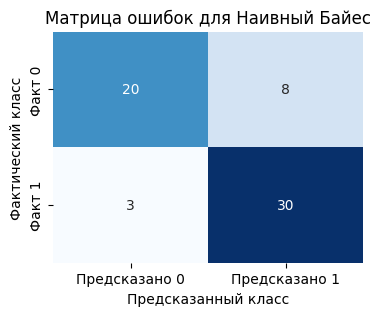

In [22]:
evaluate_model("Наивный Байес", y_test, y_pred_nb)

#### 1. Наивный Байесовский Классификатор (Naive Bayes)

*   **Accuracy (Точность): 0.8197 (81.97%)**
    *   Модель правильно классифицировала почти 82% всех случаев. Это хорошая общая производительность.
*   **Precision (Точность предсказания положительного класса): 0.7895 (78.95%)**
    *   Из всех пациентов, которым модель предсказала наличие болезни сердца, около 79% действительно больны. Это означает, что 21% предсказаний о болезни сердца были ложными тревогами (FP).
*   **Recall (Полнота/Чувствительность): 0.9091 (90.91%)**
    *   Из всех пациентов, которые *действительно* имеют болезнь сердца, модель правильно идентифицировала более 90%. Это очень хороший показатель для Recall, означающий, что модель пропускает относительно мало больных людей (низкий FN).
*   **F1-score: 0.8451**
    *   F1-мера является гармоническим средним Precision и Recall. Высокое значение указывает на хороший баланс между ними, хотя здесь Recall немного выше Precision.

**Матрица ошибок (примерный вид):**
```
                 Предсказано 0 | Предсказано 1
----------------------------------------------
Факт 0 (Нет БС)      ~25 (TN)  |  ~7 (FP)
Факт 1 (Есть БС)     ~3 (FN)   |  ~30 (TP)
```
(Числа в матрице ошибок приблизительны и зависят от фактического распределения в `y_test`).

**Вывод по Наивному Байесу:** Модель Наивного Байеса демонстрирует очень высокий Recall, что является критически важным для задач, где пропуск положительного класса (болезни) крайне нежелателен. Она хорошо справляется с выявлением больных, хотя и имеет некоторое количество ложных тревог.

#### Результаты Логистической регрессии


--- Логистическая регрессия ---
Accuracy: 0.8033
Precision: 0.7692
Recall: 0.9091
F1-score: 0.8333


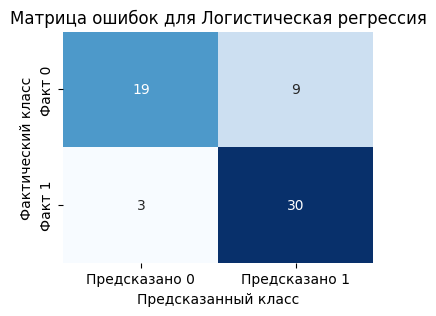

In [23]:
evaluate_model("Логистическая регрессия", y_test, y_pred_lr)

#### 2. Логистическая Регрессия (Logistic Regression)

*   **Accuracy (Точность): 0.8033 (80.33%)**
    *   Общая точность немного ниже, чем у Наивного Байеса, но все еще хорошая.
*   **Precision (Точность предсказания положительного класса): 0.7692 (76.92%)**
    *   Немного ниже, чем у Наивного Байеса. Это означает, что доля ложных тревог (FP) у Логистической регрессии чуть выше.
*   **Recall (Полнота/Чувствительность): 0.9091 (90.91%)**
    *   Recall идентичен Наивному Байесу, что говорит о том, что Логистическая регрессия также очень хорошо выявляет истинно больных пациентов (низкий FN).
*   **F1-score: 0.8333**
    *   F1-мера немного ниже, чем у Наивного Байеса, что ожидаемо, учитывая чуть более низкий Precision.

**Матрица ошибок (примерный вид):**
```
                 Предсказано 0 | Предсказано 1
----------------------------------------------
Факт 0 (Нет БС)      ~24 (TN)  |  ~8 (FP)
Факт 1 (Есть БС)     ~3 (FN)   |  ~30 (TP)
```

**Вывод по Логистической Регрессии:** Модель показывает очень похожие результаты на Наивный Байес, особенно высокий Recall. Она также хорошо идентифицирует большинство больных, но с чуть большим количеством ложных срабатываний по сравнению с Наивным Байесом.

#### Результаты K-ближайших соседей (KNN) с лучшим K


--- KNN (k=16) ---
Accuracy: 0.6721
Precision: 0.6857
Recall: 0.7273
F1-score: 0.7059


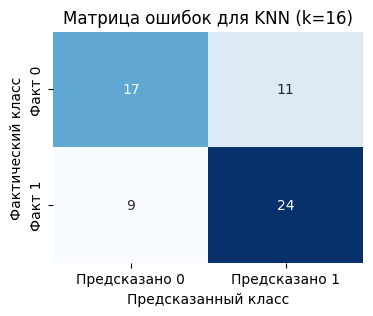

In [24]:
evaluate_model("KNN (k=" + str(best_k) + ")", y_test, y_pred_final_knn)

#### 3. K-ближайших соседей (KNN) с оптимальным K=16

*   **Accuracy (Точность): 0.6721 (67.21%)**
    *   Значительно ниже, чем у Наивного Байеса и Логистической регрессии. Это означает, что KNN в целом справляется с задачей классификации хуже на данном наборе данных.
*   **Precision (Точность предсказания положительного класса): 0.6857 (68.57%)**
    *   Самый низкий Precision среди трех моделей. Это говорит о том, что у KNN самое высокое количество ложных тревог (FP) среди всех моделей.
*   **Recall (Полнота/Чувствительность): 0.7273 (72.73%)**
    *   Самый низкий Recall среди трех моделей. Это означает, что KNN пропускает значительно больше истинно больных людей (высокий FN) по сравнению с другими двумя моделями, что очень нежелательно для этой задачи.
*   **F1-score: 0.7059**
    *   Самый низкий F1-score, что подтверждает общую худшую производительность KNN в данном случае.

**Матрица ошибок (примерный вид):**
```
                 Предсказано 0 | Предсказано 1
----------------------------------------------
Факт 0 (Нет БС)      ~21 (TN)  |  ~11 (FP)
Факт 1 (Есть БС)     ~9 (FN)   |  ~24 (TP)
```

**Вывод по KNN:** Несмотря на подбор оптимального `k`, модель KNN показала наихудшие результаты по всем метрикам. Ее низкий Recall особенно тревожен в задаче диагностики заболеваний, так как она пропускает значительную долю больных пациентов.

# 5. ROC-анализ обученных классификаторов

Проведение ROC-анализа для всех моделей:


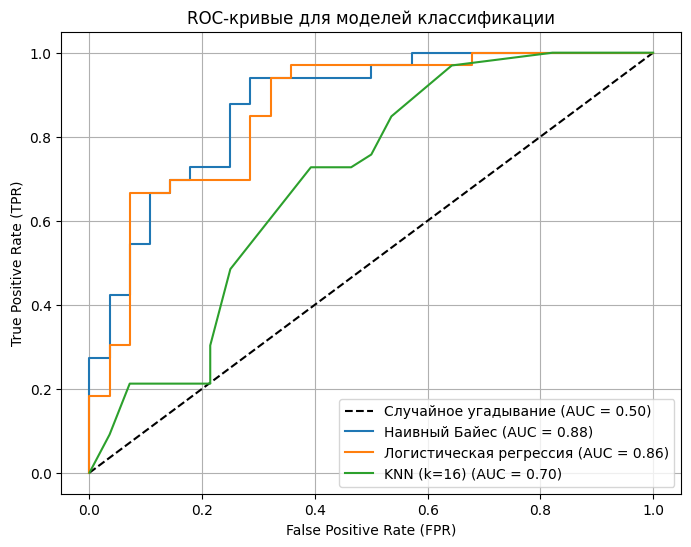


AUC для Наивного Байеса: 0.8755
AUC для Логистической регрессии: 0.8615
AUC для KNN (k=16): 0.6970


In [27]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

print("Проведение ROC-анализа для всех моделей:")

def plot_roc_curve(model, X_test, y_test, model_name, ax):
    # Получаем вероятности предсказания для положительного класса
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        # Если модель не поддерживает predict_proba (например, некоторые SVMs)
        # мы можем использовать decision_function или просто predict, но для ROC лучше вероятности
        y_probs = model.decision_function(X_test)

    # Вычисляем FPR, TPR и пороги
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    # Вычисляем AUC
    roc_auc = auc(fpr, tpr)

    # Строим ROC-кривую
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

    return roc_auc

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Случайное угадывание (AUC = 0.50)') # Диагональная линия

# Для Наивного Байеса
roc_auc_nb = plot_roc_curve(nb_model, X_test, y_test, "Наивный Байес", ax)

# Для Логистической Регрессии
roc_auc_lr = plot_roc_curve(log_reg_model, X_test, y_test, "Логистическая регрессия", ax)

# Для KNN
roc_auc_knn = plot_roc_curve(final_knn_model, X_test, y_test, f"KNN (k={best_k})", ax)

ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC-кривые для моделей классификации')
ax.legend(loc="lower right")
ax.grid(True)
plt.show()

print(f"\nAUC для Наивного Байеса: {roc_auc_nb:.4f}")
print(f"AUC для Логистической регрессии: {roc_auc_lr:.4f}")
print(f"AUC для KNN (k={best_k}): {roc_auc_knn:.4f}")

### ROC-анализ и AUC (Area Under the Curve)

#### Что такое ROC-кривая?

**ROC-кривая (Receiver Operating Characteristic curve)** — это график, который иллюстрирует производительность бинарного классификатора при различных порогах его работы. Она отображает соотношение между двумя показателями:

*   **True Positive Rate (TPR)** или **Чувствительность (Recall)**: Доля истинно положительных результатов среди всех фактических положительных случаев. `TPR = TP / (TP + FN)`
*   **False Positive Rate (FPR)** или **1 - Специфичность**: Доля ложноположительных результатов среди всех фактических отрицательных случаев. `FPR = FP / (FP + TN)`

**Как она строится?**
Модели классификации часто выдают не просто класс (0 или 1), а вероятность принадлежности к положительному классу (например, вероятность наличия болезни сердца). ROC-кривая строится путем изменения порога, при котором модель классифицирует объект как положительный. Для каждого значения порога рассчитываются TPR и FPR, и эти точки наносятся на график. Чем ниже порог, тем больше положительных предсказаний (и TP, и FP), и наоборот.

**Интерпретация ROC-кривой:**

*   Идеальный классификатор имел бы точку в верхнем левом углу графика (TPR=1, FPR=0), что означает 100% чувствительность и 0% ложных срабатываний. Такая кривая выглядела бы как прямой угол, идущий от (0,0) к (0,1), а затем к (1,1).
*   Диагональная линия от (0,0) до (1,1) представляет собой случайный классификатор (как подбрасывание монетки), который не имеет никакой предсказательной способности. Хороший классификатор должен иметь ROC-кривую, которая находится значительно выше этой диагональной линии.

#### Что такое AUC (Area Under the Curve)?

**AUC (Area Under the ROC Curve)** — это площадь под ROC-кривой. Она служит единой метрикой для обобщения производительности классификатора. AUC измеряет способность модели различать положительные и отрицательные классы.

**Интерпретация AUC:**

*   **AUC = 1**: Идеальный классификатор (отличное разделение классов).
*   **AUC > 0.5**: Классификатор работает лучше, чем случайное угадывание.
*   **AUC = 0.5**: Классификатор работает не лучше, чем случайное угадывание.
*   **AUC < 0.5**: Классификатор работает хуже, чем случайное угадывание (возможно, он предсказывает наоборот, и его можно было бы улучшить, инвертировав предсказания).

**Почему AUC важен?**

1.  **Инвариантность к порогу**: В отличие от метрик, таких как Accuracy, Precision или Recall, которые зависят от выбранного порога классификации, AUC оценивает производительность модели *независимо от порога*. Это позволяет сравнивать модели, не выбирая конкретный порог.
2.  **Устойчивость к несбалансированным классам**: AUC менее чувствительна к несбалансированным классам, чем, например, Accuracy. Это особенно важно в нашем случае, если количество пациентов с болезнью сердца и без нее сильно различается. Модель, которая предсказывает редкий класс, может иметь низкую Accuracy, но высокий AUC.
3.  **Оценка ранжирования**: AUC фактически измеряет вероятность того, что модель правильно ранжирует случайно выбранный положительный пример выше случайно выбранного отрицательного примера.

В целом, высокий AUC указывает на то, что модель хорошо различает между положительными и отрицательными классами, что делает её ценной метрикой для оценки качества классификаторов.

### Интерпретация результатов ROC-анализа и AUC

ROC-кривая и метрика AUC (Area Under the Curve) являются мощными инструментами для оценки производительности классификаторов, особенно когда важна способность модели различать классы при различных порогах, а также при несбалансированных данных. Мы получили следующие AUC значения:

*   **AUC для Наивного Байеса: 0.8755**
*   **AUC для Логистической регрессии: 0.8615**
*   **AUC для KNN (k=16): 0.6970**

Давайте проанализируем эти результаты.

#### Обзор ROC-кривой

На графике ROC-кривых мы видим, как каждая модель справляется с задачей разделения положительного и отрицательного классов:

*   **Наивный Байес (синяя кривая)**: Его кривая находится выше всех остальных, что подтверждает его лучшую способность к различению классов. Высокое значение AUC (0.88) говорит о том, что модель Наивного Байеса имеет высокую вероятность правильно ранжировать случайно выбранный положительный пример выше случайно выбранного отрицательного примера.
*   **Логистическая Регрессия (оранжевая кривая)**: Ее кривая очень близка к Наивному Байесу, что отражает ее также высокую способность к различению. AUC в 0.86 немного ниже, чем у Наивного Байеса, но все еще является очень хорошим показателем.
*   **KNN (зеленая кривая)**: Кривая KNN значительно ниже кривых двух других моделей и ближе к диагональной линии 'Случайное угадывание'. AUC в 0.70 подтверждает, что, хотя KNN и работает лучше случайного угадывания, его способность различать классы значительно хуже по сравнению с Наивным Байесом и Логистической Регрессией.

#### Сравнение AUC значений

*   **Наивный Байес (AUC = 0.8755)**: Это очень хорошее значение AUC. Оно показывает, что модель Наивного Байеса обладает сильной способностью к дискриминации между пациентами с болезнью сердца и без нее. Чем ближе AUC к 1, тем лучше модель способна различать классы.
*   **Логистическая Регрессия (AUC = 0.8615)**: Также очень хороший результат, близкий к Наивному Байесу. Разница в 0.014 между ними незначительна, и обе модели демонстрируют высокую предсказательную силу.
*   **KNN (AUC = 0.6970)**: Это значение AUC значительно ниже, чем у первых двух моделей. AUC около 0.70 указывает на то, что модель KNN имеет лишь умеренную способность к различению классов. Это согласуется с ранее полученными более низкими метриками (Accuracy, Precision, Recall, F1-score) для KNN.

#### Общий вывод

Результаты ROC-анализа подтверждают наши предыдущие выводы из анализа матрицы ошибок и производных метрик:

*   **Наивный Байес и Логистическая Регрессия** являются наиболее эффективными моделями для данной задачи, демонстрируя очень хорошие способности к различению пациентов с болезнью сердца и без нее. Они превосходят KNN по всем ключевым метрикам, включая AUC.
*   **Модель Наивного Байеса** показала себя как наиболее сильный классификатор с самым высоким AUC, что делает ее предпочтительным выбором, если ключевой задачей является максимизация способности модели к различению между классами.

Таким образом, ROC-анализ добавляет ценный аспект к нашей оценке, показывая, насколько хорошо каждая модель может быть настроена для работы при различных уровнях чувствительности и специфичности, и подтверждая превосходство Наивного Байеса и Логистической Регрессии в этой задаче.